# Random forest Model Training

In [91]:
import pandas as pd

In [92]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load features and labels
- load features development set
- load labels of development set
- load features of test set

In [93]:
drive_path = "/content/drive/MyDrive/ML/"
X_dev_final = "X_dev_final.csv"
#X_dev_final = "X_dev_extended.csv"
y_file = "y_train.csv"
X_test_final = "X_test_final.csv"
#X_test_final = "X_test_extended.csv"
#X_test_final = "X_test_extended_full_model.csv"

X_dev = pd.read_csv(drive_path + X_dev_final)
y_file = pd.read_csv(drive_path + y_file)
X_test = pd.read_csv(drive_path + X_test_final)

assert X_dev.shape[0] == y_file.shape[0], "Number of samples in X_dev and y_file must be the same."
# check weather column names of test and dev are matching except for fold column
print("Column names in X_dev:", set(X_dev.columns))
print("Column names in X_test:", set(X_test.columns))
print("Columns in X_dev but not in X_test:", set(X_dev.columns) - set(X_test.columns))
print("Columns in X_test but not in X_dev:", set(X_test.columns) - set(X_dev.columns))



Column names in X_dev: {'cancer_history', 'region_ARM', 'diameter_1', 'fold', 'region_EAR', 'perimeter', 'roundness', 'region_ABDOMEN', 'background_mother_UNK', 'gender', 'background_mother_NORWAY', 'background_father_CZECH', 'lbp_bin_2', 'mean_B', 'background_mother_GERMANY', 'diameter_2', 'edge_count', 'lbp_bin_0', 'img_id', 'changed', 'grew', 'bleed', 'background_mother_SPAIN', 'mean_G', 'background_father_GERMANY', 'region_NECK', 'region_BACK', 'std_B', 'background_father_AUSTRIA', 'background_father_ISRAEL', 'region_THIGH', 'background_father_POMERANIA', 'background_mother_NETHERLANDS', 'background_mother_POLAND', 'background_mother_PORTUGAL', 'background_father_BRAZIL', 'has_sewage_system', 'hurt', 'background_father_PORTUGAL', 'fitspatrick', 'background_father_POLAND', 'region_NOSE', 'skin_cancer_history', 'elevation', 'background_mother_POMERANIA', 'region_FACE', 'no_hurt', 'drink', 'region_CHEST', 'area', 'lbp_bin_6', 'region_HAND', 'lbp_bin_4', 'background_father_BRASIL', 'ba

In [94]:
# Randomly checking weather patient ids match between X_dev and y_file
#create random array with 10 random indices
import numpy as np
random_indices = np.random.choice(X_dev.shape[0], size=10, replace=False)
for idx in random_indices:
    assert X_dev['patient_id'].iloc[idx] == y_file['patient_id'].iloc[idx], f"Patient IDs do not match at index {idx} between X_dev and y_file."

# Keep unique image ids for later per-sample CV analysis
dev_image_ids = X_dev['img_id'].copy()
assert dev_image_ids.is_unique, "img_id should be unique in X_dev for reliable sample tracking."

# remove patient_id column and image)_id column from X_dev
X_dev = X_dev.drop(columns=['patient_id', 'img_id'])
X_test_features = X_test.drop(columns=['patient_id', 'img_id'])


In [95]:
from sklearn.preprocessing import LabelEncoder

# Create separate encoders
le_fine = LabelEncoder()
le_coarse = LabelEncoder()

# Fit and transform separately
y_fine = le_fine.fit_transform(y_file['fine_label'])
y_coarse = le_coarse.fit_transform(y_file['coarse_label'])

print("Fine label encoder classes:", le_fine.classes_)
print("Coarse label encoder classes:", le_coarse.classes_)
display(y_fine[:30])
display(y_coarse[:30])


Fine label encoder classes: ['ACK' 'BCC' 'MEL' 'NEV' 'SCC' 'SEK']
Coarse label encoder classes: [0 1]


array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 1, 3, 1, 3,
       0, 1, 0, 4, 2, 1, 4, 1])

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1])

## 2. Construct Grid
- Include hyperparameters: max_features=[3, 10, 33, 100, 333], max_depth=[16, 32, None], min_samples_leaf=[1,2,3,4,5],min_sample_split=[2,3], min_estimators=[100], random_state=[101], criterion=['entropy'].

In [96]:
# forest_hyperparameter_grid_by_name = dict(
#     max_features=[3, 10, 33, 100, 333],
#     max_depth=[16, 32, None],
#     min_samples_leaf=[1,2,3,4,5],
#     n_estimators=[100],
#     random_state=[101],
#     criterion=['entropy']
#     )
forest_hyperparameter_grid_by_name = dict(
    max_features=[3],
    max_depth=[16],
    min_samples_leaf=[2],
    n_estimators=[100, 500, 1000],
    random_state=[101],
    criterion=['entropy']
    )





## 3. Hyperparameter search on fine labels

In [97]:
import numpy as np
import pandas as pd
from sklearn.model_selection import PredefinedSplit, GridSearchCV, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Shared split and feature matrix
fold = X_dev["fold"].to_numpy()
ps = PredefinedSplit(fold)
X_dev_features = X_dev.drop(columns=["fold"] )

# Print fold diagnostics so CV progress is easier to follow
unique_folds, fold_counts = np.unique(fold, return_counts=True)
print("PredefinedSplit fold summary:")
for fold_id, n_samples in zip(unique_folds, fold_counts):
    print(f"  fold={fold_id}: {n_samples} samples")

print("\nDerived train/validation sizes per split:")
for i, (train_idx, val_idx) in enumerate(ps.split(X_dev_features, y_fine), start=1):
    print(f"  split {i}: train={len(train_idx)} valid={len(val_idx)}")

# Fine -> coarse mapping used for scorer and final evaluation
fine_to_coarse_mapping = {
    "BCC": 1, "MEL": 1, "SCC": 1, "ACK": 1,
    "NEV": 0, "SEK": 0
}

def coarse_auc_cv_scorer(estimator, X_val, y_true_fine_encoded):
    y_true_fine_encoded = np.asarray(y_true_fine_encoded, dtype=np.int64)

    # Convert encoded fine true labels -> coarse labels
    y_true_fine_labels = le_fine.inverse_transform(y_true_fine_encoded)
    y_true_coarse = np.array(
        [fine_to_coarse_mapping[label] for label in y_true_fine_labels],
        dtype=np.int64
    )

    # Use fold-specific class order from fitted estimator
    y_pred_proba_fine = estimator.predict_proba(X_val)
    fold_fine_labels = le_fine.inverse_transform(estimator.classes_)
    malignant_cols = np.array(
        [fine_to_coarse_mapping[label] == 1 for label in fold_fine_labels],
        dtype=bool
    )

    p_malignant = y_pred_proba_fine[:, malignant_cols].sum(axis=1)

    # AUROC guard if a fold is degenerate
    if np.unique(y_true_coarse).size < 2:
        return 0.5

    return roc_auc_score(y_true_coarse, p_malignant)

fine_searcher = GridSearchCV(
    estimator=RandomForestClassifier(verbose=1),
    param_grid=forest_hyperparameter_grid_by_name,
    cv=ps,
    scoring=coarse_auc_cv_scorer,
    return_train_score=True,
    refit=False,
    n_jobs=-1,
    verbose=2
)

print("\nStarting fine-label grid search...")
fine_searcher.fit(X_dev_features, y_fine)
print("Grid search finished.\n")

fine_results_df = pd.DataFrame(fine_searcher.cv_results_)

# Keep per-fold test scores so each hyperparameter constellation includes fold-level detail
split_test_cols = sorted([c for c in fine_results_df.columns if c.startswith("split") and c.endswith("_test_score")])
results_with_folds = fine_results_df[["params", "mean_test_score", "std_test_score", "mean_train_score", "std_train_score"] + split_test_cols].copy()

display(
    results_with_folds
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)

# Top-3 and bottom-3 hyperparameter constellations by CV mean test score
top3_configs = results_with_folds.sort_values("mean_test_score", ascending=False).head(3).copy()
bottom3_configs = results_with_folds.sort_values("mean_test_score", ascending=True).head(3).copy()

print("Top 3 hyperparameter constellations:")
display(top3_configs)
print("Bottom 3 hyperparameter constellations:")
display(bottom3_configs)

# For each constellation, collect 3 highest-performing and 3 lowest-performing samples by unique img_id
y_true_coarse = y_coarse.astype(np.int64)
sample_extremes = []

for _, row in results_with_folds.iterrows():
    params = row["params"]
    estimator = RandomForestClassifier(**params, verbose=0)

    # Out-of-fold probabilities: each sample scored only on its validation fold
    oof_proba_fine = cross_val_predict(
        estimator,
        X_dev_features,
        y_fine,
        cv=ps,
        method="predict_proba",
        n_jobs=-1
    )

    # Convert fine-class probabilities to malignant probability
    all_fine_labels = le_fine.inverse_transform(np.arange(oof_proba_fine.shape[1]))
    malignant_cols_global = np.array(
        [fine_to_coarse_mapping[label] == 1 for label in all_fine_labels],
        dtype=bool
    )
    p_malignant = oof_proba_fine[:, malignant_cols_global].sum(axis=1)

    # Per-sample performance proxy on coarse task: probability assigned to the true coarse class
    p_true_coarse = np.where(y_true_coarse == 1, p_malignant, 1.0 - p_malignant)

    top_idx = np.argsort(-p_true_coarse)[:3]
    bottom_idx = np.argsort(p_true_coarse)[:3]

    sample_extremes.append({
        "params": params,
        "mean_test_score": float(row["mean_test_score"]),
        "top3_img_id": dev_image_ids.iloc[top_idx].tolist(),
        "top3_p_true": p_true_coarse[top_idx].round(6).tolist(),
        "bottom3_img_id": dev_image_ids.iloc[bottom_idx].tolist(),
        "bottom3_p_true": p_true_coarse[bottom_idx].round(6).tolist(),
    })

sample_extremes_by_config = pd.DataFrame(sample_extremes).sort_values("mean_test_score", ascending=False)

print("Per-constellation sample extremes (sorted by CV score):")
display(sample_extremes_by_config)

print("Fine-label model (evaluated on coarse AUROC)")
print(f"Best score: {fine_searcher.best_score_:.4f}")
print(f"Best params: {fine_searcher.best_params_}")

# Optional: sample extremes for the final best constellation only
best_constellation_samples = sample_extremes_by_config[sample_extremes_by_config["params"] == fine_searcher.best_params_].head(1)
print("Best-constellation top/bottom samples by img_id:")
display(best_constellation_samples)

PredefinedSplit fold summary:
  fold=0: 236 samples
  fold=1: 235 samples
  fold=2: 235 samples
  fold=3: 235 samples
  fold=4: 237 samples

Derived train/validation sizes per split:
  split 1: train=942 valid=236
  split 2: train=943 valid=235
  split 3: train=943 valid=235
  split 4: train=943 valid=235
  split 5: train=941 valid=237

Starting fine-label grid search...
Fitting 5 folds for each of 3 candidates, totalling 15 fits


Grid search finished.



,params,mean_test_score,std_test_score,mean_train_score,std_train_score,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score
1,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.903548,0.031573,0.999977,0.000017,0.885050,0.860707,0.953488,0.920377,0.898117
2,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.901414,0.033395,0.999984,0.000015,0.881063,0.855509,0.953256,0.920091,0.897151
0,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.893591,0.031759,0.999885,0.000133,0.866002,0.853777,0.943488,0.907534,0.897151


Top 3 hyperparameter constellations:


,params,mean_test_score,std_test_score,mean_train_score,std_train_score,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score
1,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.903548,0.031573,0.999977,0.000017,0.885050,0.860707,0.953488,0.920377,0.898117
2,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.901414,0.033395,0.999984,0.000015,0.881063,0.855509,0.953256,0.920091,0.897151
0,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.893591,0.031759,0.999885,0.000133,0.866002,0.853777,0.943488,0.907534,0.897151


...

,params,mean_test_score,std_test_score,mean_train_score,std_train_score,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score
0,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.893591,0.031759,0.999885,0.000133,0.866002,0.853777,0.943488,0.907534,0.897151
2,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.901414,0.033395,0.999984,0.000015,0.881063,0.855509,0.953256,0.920091,0.897151
1,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.903548,0.031573,0.999977,0.000017,0.885050,0.860707,0.953488,0.920377,0.898117


Per-constellation sample extremes (sorted by CV score):


,params,mean_test_score,top3_img_id,top3_p_true,bottom3_img_id,bottom3_p_true
1,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.903548,"[PAT_007_198, PAT_068_464, PAT_690_398]","[0.996117, 0.99606, 0.995895]","[PAT_779_755, PAT_779_575, PAT_287_1441]","[0.039807, 0.04134, 0.04402]"
2,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.901414,"[PAT_743_1424, PAT_068_464, PAT_327_1273]","[0.996598, 0.99533, 0.994071]","[PAT_779_575, PAT_779_755, PAT_287_1441]","[0.033158, 0.042386, 0.043576]"
0,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.893591,"[PAT_512_957, PAT_759_007, PAT_603_992]","[1.0, 1.0, 1.0]","[PAT_771_915, PAT_779_575, PAT_287_1441]","[0.030333, 0.037763, 0.041594]"


Fine-label model (evaluated on coarse AUROC)
Best score: 0.9035
Best params: {'criterion': 'entropy', 'max_depth': 16, 'max_features': 3, 'min_samples_leaf': 2, 'n_estimators': 500, 'random_state': 101}
Best-constellation top/bottom samples by img_id:


,params,mean_test_score,top3_img_id,top3_p_true,bottom3_img_id,bottom3_p_true
1,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.903548,"[PAT_007_198, PAT_068_464, PAT_690_398]","[0.996117, 0.99606, 0.995895]","[PAT_779_755, PAT_779_575, PAT_287_1441]","[0.039807, 0.04134, 0.04402]"


In [21]:
# Coarse-label baseline model for comparison
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestClassifier

# coarse_searcher = GridSearchCV(
#     estimator=RandomForestClassifier(),
#     param_grid=forest_hyperparameter_grid_by_name,
#     cv=ps,
#     scoring="roc_auc",
#     return_train_score=True,
#     refit=False,
#     n_jobs=-1
# )

# coarse_searcher.fit(X_dev_features, y_coarse)

# coarse_results_df = pd.DataFrame(coarse_searcher.cv_results_)
# display(
#     coarse_results_df[["params", "mean_test_score", "std_test_score", "mean_train_score", "std_train_score"]]
#     .sort_values("mean_test_score", ascending=False)
#     .head(10)
# )
# print(f"Coarse-label model best score: {coarse_searcher.best_score_:.4f}")
# print(f"Coarse-label model best params: {coarse_searcher.best_params_}")

In [80]:
# Fit final models using best hyperparameters from each search
print("Starting final fit for fine-label model...")
best_forest_fine = RandomForestClassifier(**fine_searcher.best_params_, verbose=1)
best_forest_fine.fit(X_dev_features, y_fine)
print("Final fine-label fit complete.")

# best_forest_coarse = RandomForestClassifier(**coarse_searcher.best_params_)
# best_forest_coarse.fit(X_dev_features, y_coarse)

print("Fine model best params:", fine_searcher.best_params_)
# print("Coarse model best params:", coarse_searcher.best_params_)

Starting final fit for fine-label model...
Final fine-label fit complete.
Fine model best params: {'criterion': 'entropy', 'max_depth': 16, 'max_features': 3, 'min_samples_leaf': 2, 'n_estimators': 100, 'random_state': 101}


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.3s finished


In [81]:
# Preview predicted fine labels from the fine-trained model
y_pred_fine = best_forest_fine.predict(X_dev_features)
y_pred_fine_labels = le_fine.inverse_transform(y_pred_fine)
display(y_pred_fine_labels[:30])

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


array(['BCC', 'BCC', 'BCC', 'BCC', 'ACK', 'BCC', 'BCC', 'BCC', 'BCC',
       'BCC', 'BCC', 'BCC', 'BCC', 'BCC', 'BCC', 'BCC', 'BCC', 'BCC',
       'BCC', 'NEV', 'BCC', 'NEV', 'BCC', 'BCC', 'ACK', 'SCC', 'MEL',
       'BCC', 'SCC', 'BCC'], dtype=object)

## 4. Report AUROC on coarse labels

In [82]:
# Evaluate both models on development coarse AUROC
from sklearn.metrics import roc_auc_score
import numpy as np

# Ground-truth coarse labels as binary integers
y_true_coarse = y_coarse

# Fine-trained model: sum malignant fine-class probabilities
y_pred_proba_fine = best_forest_fine.predict_proba(X_dev_features)
fine_class_labels = le_fine.inverse_transform(best_forest_fine.classes_)
malignant_cols = np.array([fine_to_coarse_mapping[label] == 1 for label in fine_class_labels], dtype=bool)
p_malignant_from_fine = y_pred_proba_fine[:, malignant_cols].sum(axis=1)

# Coarse-trained model: probability of malignant class (label 1)
# coarse_class_index = int(np.where(best_forest_coarse.classes_ == 1)[0][0])
# p_malignant_from_coarse = best_forest_coarse.predict_proba(X_dev_features)[:, coarse_class_index]

fine_model_dev_auc = roc_auc_score(y_true_coarse, p_malignant_from_fine)
# coarse_model_dev_auc = roc_auc_score(y_true_coarse, p_malignant_from_coarse)

print(f"Fine-trained model (coarse AUROC): {fine_model_dev_auc:.4f}")
# print(f"Coarse-only model (coarse AUROC): {coarse_model_dev_auc:.4f}")


Fine-trained model (coarse AUROC): 0.9999


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [25]:
# Final comparison table
# comparison_df = pd.DataFrame({
#     "model": [
#         "Fine labels -> coarse evaluation",
#         "Coarse labels only"
#     ],
#     "cv_mean_auroc": [
#         fine_searcher.best_score_,
#         coarse_searcher.best_score_
#     ],
#     "dev_auroc": [
#         fine_model_dev_auc,
#         coarse_model_dev_auc
#     ],
#     "best_params": [
#         str(fine_searcher.best_params_),
#         str(coarse_searcher.best_params_)
#     ]
# }).sort_values("cv_mean_auroc", ascending=False)

# display(comparison_df)
# print("CV winner:", comparison_df.iloc[0]["model"])

## 5. Train 500 estimators with best parameters

In [83]:
#constuct y_test predictions for submission
y_test_path = 'yproba1(2)_test.txt'
#one line for each sample with the predicted probability of being positive(malignant)

y_test_fine = best_forest_fine.predict(X_test_features)
y_test_fine_labels = le_fine.inverse_transform(y_test_fine)
display(y_test_fine_labels[:30])
# Fine-trained model: sum malignant fine-class probabilities
y_test_proba_fine = best_forest_fine.predict_proba(X_test_features)
fine_class_labels = le_fine.inverse_transform(best_forest_fine.classes_)
malignant_cols = np.array([fine_to_coarse_mapping[label] == 1 for label in fine_class_labels], dtype=bool)
p_malignant_from_fine = y_test_proba_fine[:, malignant_cols].sum(axis=1)


pd.Series(p_malignant_from_fine).to_csv(y_test_path, index=False, header=False)

#loadable into numpy with np.loadtxt(y_test_path)
y_test = np.loadtxt(y_test_path)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


array(['BCC', 'BCC', 'BCC', 'BCC', 'BCC', 'ACK', 'BCC', 'BCC', 'BCC',
       'BCC', 'NEV', 'BCC', 'BCC', 'BCC', 'BCC', 'BCC', 'BCC', 'BCC',
       'ACK', 'BCC', 'ACK', 'ACK', 'BCC', 'BCC', 'BCC', 'BCC', 'BCC',
       'BCC', 'NEV', 'BCC'], dtype=object)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


## 6. Plot n_estimators

In [44]:
forest_hyperparameter_grid_by_name = dict(
    max_features=[3],
    max_depth=[16],
    min_samples_leaf=[2],
    n_estimators=[1, 10, 25, 50, 100, 200, 500, 1000],
    random_state=[101],
    criterion=['entropy']
    )


fine_searcher = GridSearchCV(
    estimator=RandomForestClassifier(verbose=1),
    param_grid=forest_hyperparameter_grid_by_name,
    cv=ps,
    scoring=coarse_auc_cv_scorer,
    return_train_score=True,
    refit=False,
    n_jobs=-1,
    verbose=2
)

print("\nStarting fine-label grid search...")
fine_searcher.fit(X_dev_features, y_fine)
print("Grid search finished.\n")

fine_results_df = pd.DataFrame(fine_searcher.cv_results_)
display(
    fine_results_df[["params", "mean_test_score", "std_test_score", "mean_train_score", "std_train_score"]]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)



Starting fine-label grid search...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Grid search finished.



,params,mean_test_score,std_test_score,mean_train_score,std_train_score
5,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.929004,0.027953,0.999991,0.000018
6,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.927264,0.026935,0.999994,0.000008
7,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.925489,0.028769,1.000000,0.000000
4,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.922122,0.024175,0.999960,0.000065
3,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.915775,0.027408,0.999900,0.000096
2,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.897191,0.035968,0.999718,0.000249
1,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.855976,0.047391,0.998293,0.000485
0,"{'criterion': 'entropy', 'max_depth': 16, 'max...",0.603669,0.035925,0.848777,0.029642


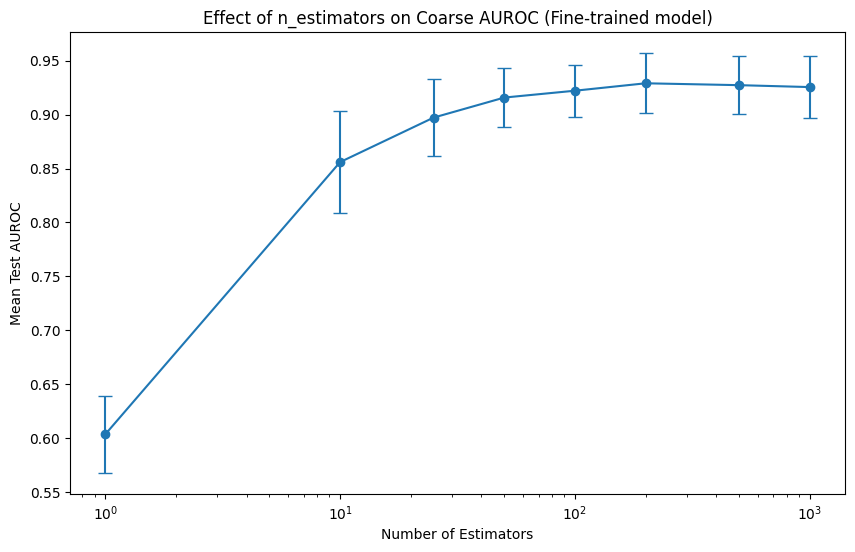

In [45]:

#plot n_estimators vs mean_test_score AUROC
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
#include vertical lines for std 
plt.errorbar(fine_results_df["param_n_estimators"], fine_results_df["mean_test_score"], yerr=fine_results_df["std_test_score"], marker='o', capsize=5)
plt.xlabel('Number of Estimators')
plt.xscale('log')
plt.ylabel('Mean Test AUROC')
plt.title('Effect of n_estimators on Coarse AUROC (Fine-trained model)')
plt.show()


## 7. Best Predictions